In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

## RED DAÑADA

In [2]:
# --- CARGAR datos ---
Omega_damage_array = np.load('../Omega_damage_list.npy')
Omega_damage_list = [Omega_damage_array[i] for i in range(Omega_damage_array.shape[0])]
A = np.load('../A_origin.npy')
G = nx.from_numpy_array(A, create_using=nx.DiGraph)


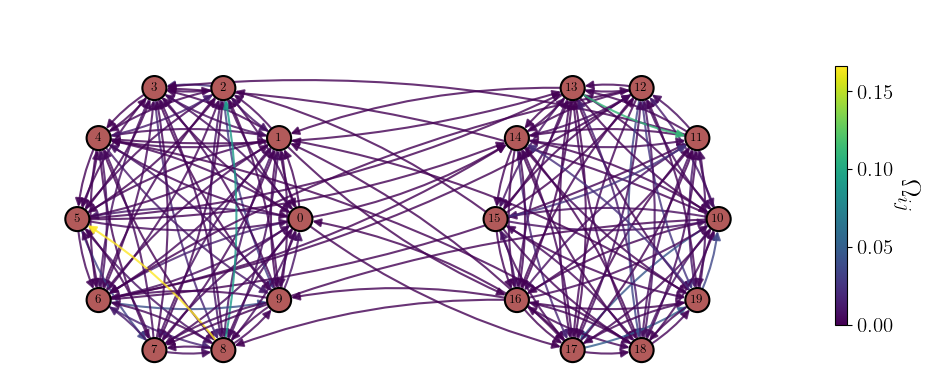

In [11]:


# Seleccionamos una matriz de peso dañada (por ejemplo, la primera simulación)
# Omega_damage_list[0]
weights_matrix = Omega_damage_list[2]

# 2. Definir posiciones (Mantenemos tu estructura de dos comunidades)
N_com = 10 
pos = {}
for i in range(N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])
for i in range(N_com, 2 * N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

# 3. Configuración de la gráfica
fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
node_colors = ['#B25A5A'] * N_com + ['#B25A5A'] * N_com

# Extraer aristas y sus pesos correspondientes de la matriz Omega
edges = list(G.edges())
weights = [weights_matrix[u, v] for u, v in edges]

# 4. Dibujar Nodos
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300, node_color=node_colors, 
                       edgecolors='black', linewidths=1.5)

# 5. Dibujar Aristas con Flechas y Curvatura
# La curvatura (connectionstyle) es vital para ver flechas i->j y j->i por separado
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                       width=1.5,
                       edge_color=weights, edge_cmap=plt.cm.viridis,
                       arrowstyle='-|>', 
                       arrowsize=12, 
                       connectionstyle='arc3,rad=0.1', 
                       alpha=0.8)

# 6. Etiquetas y Barra de Color
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color='black', font_weight='bold')

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=np.min(weights), vmax=np.max(weights)))
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label(r'$\Omega_{ij}$', rotation=270, labelpad=20, fontsize=20)
cbar.ax.tick_params(labelsize=15)

ax.axis('off')
plt.tight_layout()

savefig_name='Dos_comunidades.pdf'
plt.savefig(savefig_name,bbox_inches="tight")
plt.show()

## FUNCIONALIDAD ESTOCASTICA

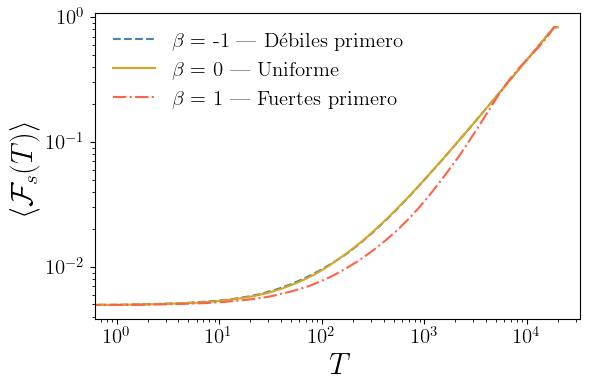

In [ ]:
avg_repair = np.load('F_Estocastica.npy', allow_pickle=True).item()

T_repair = 20000
delta_r = 0.01
betas = np.array([-1.0, 0.0, 1.0])
beta_config = {
    -1: ("Débiles primero",  "steelblue","--" ),
     0: ("Uniforme",         "goldenrod","-"),
     1: ("Fuertes primero",  "tomato","-."),
}

t_repair = np.arange(T_repair + 1)
plt.figure(figsize=(6, 4), facecolor="white")
for b in betas:
    label, color, style = beta_config[b]
    plt.loglog(t_repair, avg_repair[b],style,
             color=color, linewidth=1.5, label=r"$\beta =$"f" {b:.0f} — {label}")

plt.xlabel(r"$T$", size=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", size=22)
plt.yticks(size=15)
plt.xticks(size=15)
plt.legend(loc = 'upper left',frameon = False, fontsize=15)
plt.tight_layout()
plt.show()

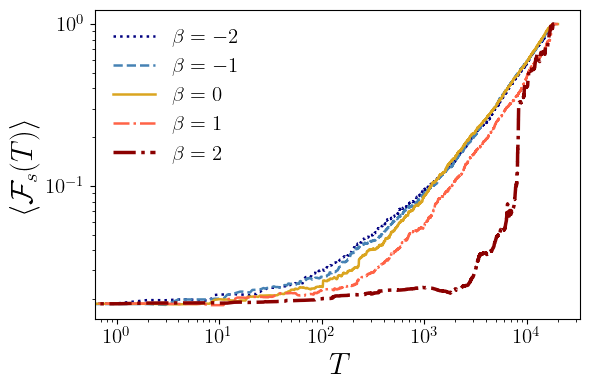

In [ ]:
avg_repair = np.load('F_Estocastica_betas.npy', allow_pickle=True).item()

# 3. Parámetros
T_repair = 25000
t_repair = np.arange(T_repair + 1)

betas = np.array([-2, -1, 0, 1, 2])

# 4. Configuración visual
beta_config = {
    -2: ("Muy débiles primero", "navy", ":", 1.8),
    -1: ("Débiles primero",     "steelblue", "--", 1.8),
     0: ("Uniforme",            "goldenrod", "-", 1.8),
     1: ("Fuertes primero",     "tomato", "-.", 1.8),
     2: ("Muy fuertes primero", "darkred", "-.", 2.5)
}


plt.figure(figsize=(6, 4), facecolor="white")
for b in betas:
    label, color, style, lw = beta_config[b]
    
    plt.loglog(
        t_repair,
        avg_repair[b],
        linestyle=style,
        color=color,
        linewidth=lw,
        label=rf"$\beta = {b:.0f}$"
    )


plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc='upper left', frameon=False, fontsize=15)


plt.tight_layout()

savefig_name='Funcionalidad_beta.pdf'
plt.savefig(savefig_name,bbox_inches="tight")
plt.show()

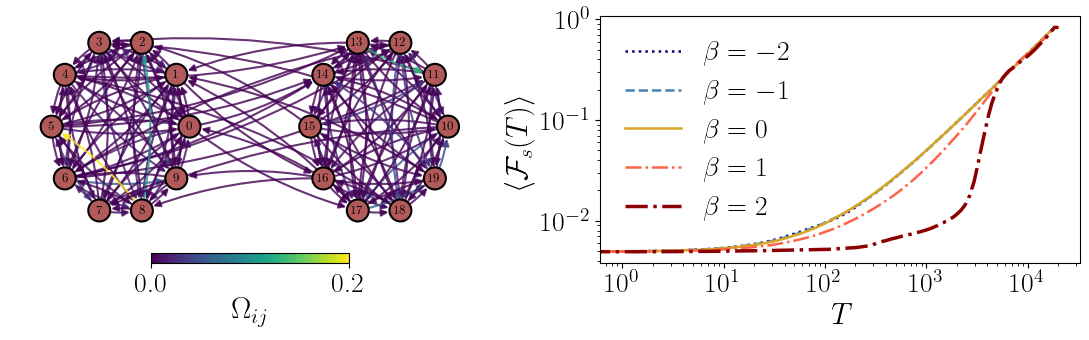

In [3]:
# =========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5), facecolor='white')

# =========================
# 🔹 GRAFO (IZQUIERDA)
# =========================

weights_matrix = Omega_damage_list[2]

N_com = 10 
pos = {}

for i in range(N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

for i in range(N_com, 2 * N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

node_colors = ['#B25A5A'] * (2 * N_com)

edges = list(G.edges())
weights = [weights_matrix[u, v] for u, v in edges]

nx.draw_networkx_nodes(G, pos, ax=ax1,
                       node_size=250,
                       node_color=node_colors,
                       edgecolors='black',
                       linewidths=1.5)

nx.draw_networkx_edges(G, pos, ax=ax1,
                       edgelist=edges,
                       width=1.5,
                       edge_color=weights,
                       edge_cmap=plt.cm.viridis,
                       arrowstyle='-|>',
                       arrowsize=10,
                       connectionstyle='arc3,rad=0.1',
                       alpha=0.8)

nx.draw_networkx_labels(G, pos, ax=ax1,
                       font_size=9,
                       font_color='black',
                       font_weight='bold')

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=np.min(weights), vmax=np.max(weights))
)

cbar = plt.colorbar(
    sm,
    ax=ax1,
    orientation='horizontal',   # clave
    pad=0.1,                  # separación con el grafo
    fraction=0.04              # tamaño de la barra
)
vmin = np.min(weights)
vmax = np.max(weights)


cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.1f}", f"{vmax:.1f}"])
cbar.set_label(r'$\Omega_{ij}$', rotation=0, labelpad=0, fontsize=22)
cbar.ax.tick_params(labelsize=20)

ax1.axis('off')


# =========================
# 🔹 CURVAS (DERECHA)
# =========================

avg_repair_1 = np.load('F_Estocastica.npy', allow_pickle=True).item()
avg_repair_2 = np.load('F_Estocastica2.npy', allow_pickle=True).item()
avg_repair = {**avg_repair_1, **avg_repair_2}

T_repair = 20000
t_repair = np.arange(T_repair + 1)

betas = np.array([-2, -1, 0, 1, 2])

beta_config = {
    -2: ("Muy débiles primero", "navy", ":", 1.8),
    -1: ("Débiles primero",     "steelblue", "--", 1.8),
     0: ("Uniforme",            "goldenrod", "-", 1.8),
     1: ("Fuertes primero",     "tomato", "-.", 1.8),
     2: ("Muy fuertes primero", "darkred", "-.", 2.5)
}

for b in betas:
    label, color, style, lw = beta_config[b]
    
    ax2.loglog(
        t_repair,
        avg_repair[b],
        linestyle=style,
        color=color,
        linewidth=lw,
        label=rf"$\beta = {b:.0f}$"
    )

ax2.set_xlabel(r"$T$", fontsize=22)
ax2.set_ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
ax2.tick_params(labelsize=20)
ax2.legend(loc='upper left', frameon=False, fontsize=20)

# =========================
# AJUSTE FINAL
# =========================
plt.tight_layout()

# Guardar todo junto
plt.savefig('Funcionalidad_DosComunidades.pdf', bbox_inches="tight")

plt.show()

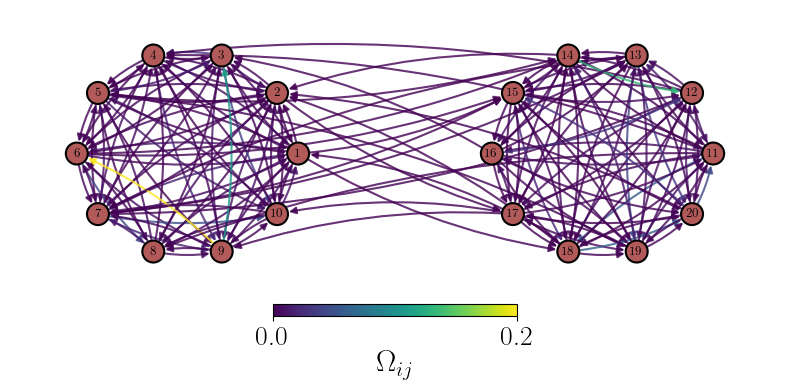

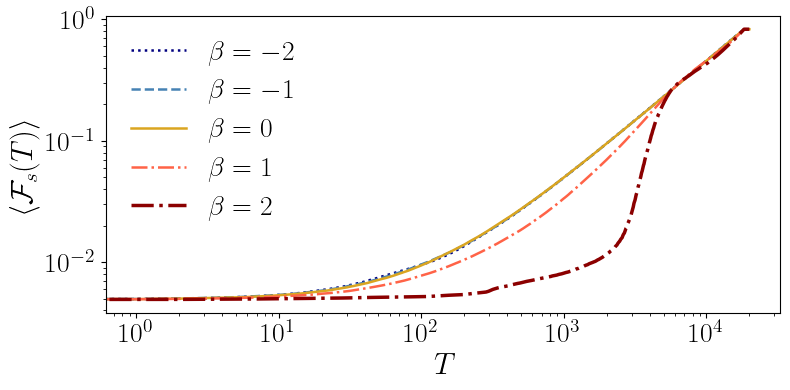

In [7]:
# =========================
# FIGURA 1: GRAFO
# =========================
fig1, ax1 = plt.subplots(1, 1, figsize=(8, 4), facecolor='white')

weights_matrix = Omega_damage_list[2]
N_com = 10
pos = {}

for i in range(N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])
for i in range(N_com, 2 * N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

node_colors = ['#B25A5A'] * (2 * N_com)
edges = list(G.edges())
weights = [weights_matrix[u, v] for u, v in edges]

nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=250, node_color=node_colors,
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=edges, width=1.5,
                       edge_color=weights, edge_cmap=plt.cm.viridis,
                       arrowstyle='-|>', arrowsize=10,
                       connectionstyle='arc3,rad=0.1', alpha=0.8)
labels = {i: str(i + 1) for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax1, font_size=9, 
                        font_color='black', font_weight='bold')

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                            norm=plt.Normalize(vmin=np.min(weights), vmax=np.max(weights)))
vmin, vmax = np.min(weights), np.max(weights)
cbar = plt.colorbar(sm, ax=ax1, orientation='horizontal', pad=0.1, fraction=0.04)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.1f}", f"{vmax:.1f}"])
cbar.set_label(r'$\Omega_{ij}$', rotation=0, labelpad=0, fontsize=22)
cbar.ax.tick_params(labelsize=20)
ax1.axis('off')

plt.tight_layout()
plt.savefig('Grafo_DosComunidades.pdf', bbox_inches='tight')
plt.show()


# =========================
# FIGURA 2: CURVAS
# =========================
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 4), facecolor='white')

avg_repair_1 = np.load('F_Estocastica.npy', allow_pickle=True).item()
avg_repair_2 = np.load('F_Estocastica2.npy', allow_pickle=True).item()
avg_repair = {**avg_repair_1, **avg_repair_2}

T_repair = 20000
t_repair = np.arange(T_repair + 1)

betas = np.array([-2, -1, 0, 1, 2])
beta_config = {
    -2: ("Muy débiles primero", "navy",     ":",   1.8),
    -1: ("Débiles primero",     "steelblue","--",  1.8),
     0: ("Uniforme",            "goldenrod","-",   1.8),
     1: ("Fuertes primero",     "tomato",   "-.",  1.8),
     2: ("Muy fuertes primero", "darkred",  "-.",  2.5),
}

for b in betas:
    label, color, style, lw = beta_config[b]
    ax2.loglog(t_repair, avg_repair[b], linestyle=style,
               color=color, linewidth=lw, label=rf"$\beta = {b:.0f}$")

ax2.set_xlabel(r"$T$", fontsize=22)
ax2.set_ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
ax2.tick_params(labelsize=20)
ax2.legend(loc='upper left', frameon=False, fontsize=20)

plt.tight_layout()
plt.savefig('Curvas_DosComunidades.pdf', bbox_inches='tight')
plt.show()

KeyError: np.float64(0.02)

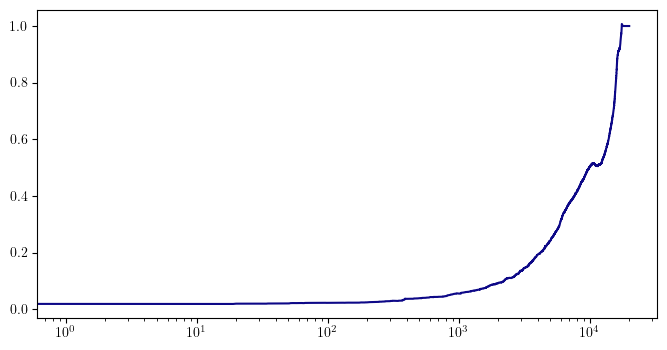

In [4]:
avg_repair = np.load('F_Estocastica_deltas.npy', allow_pickle=True).item()

T_repair = 20000
deltas_r = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1])

t_repair = np.arange(T_repair + 1)


colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())


plt.figure(figsize=(8, 4), facecolor="white")

for d in deltas_r:
    color = colormap(norm(d))
    
    plt.semilogx(   
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5,
        label=rf"$\delta_r = {d:.2f}$"
    )


plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)


plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),   
    frameon=False,
    fontsize=15
)

plt.tight_layout()
plt.show()

delta_r = 0.01 → T* = 17740
delta_r = 0.02 → T* = 8892
delta_r = 0.03 → T* = 6027
delta_r = 0.04 → T* = 4449
delta_r = 0.05 → T* = 3566
delta_r = 0.06 → T* = 3024
delta_r = 0.07 → T* = 2660
delta_r = 0.08 → T* = 2312
delta_r = 0.09 → T* = 2113
delta_r = 0.10 → T* = 1782


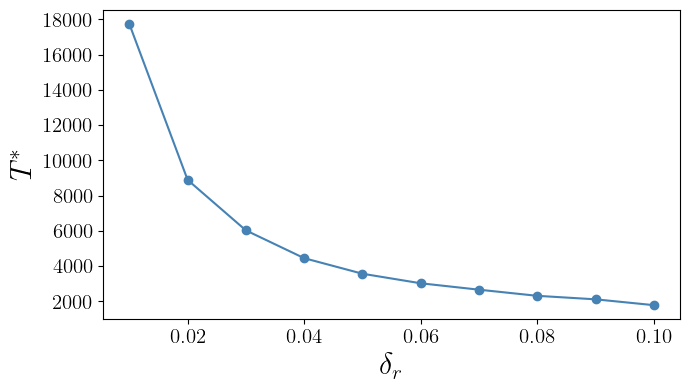

In [7]:
umbral = 0.8  # "muy cerca a 1"
tiempos_recuperacion = {}

for d in deltas_r:
    arr = avg_repair[d]
    indices = np.where(arr >= umbral)[0]
    if len(indices) > 0:
        tiempos_recuperacion[d] = indices[0]
        print(f"delta_r = {d:.2f} → T* = {indices[0]}")
    else:
        tiempos_recuperacion[d] = np.nan
        print(f"delta_r = {d:.2f} → nunca alcanzó F_s = {umbral}")

# --- GRÁFICA T* vs delta_r ---
T_star = np.array([tiempos_recuperacion[d] for d in deltas_r])

plt.figure(figsize=(7, 4), facecolor='white')
plt.plot(deltas_r, T_star, 'o-', color='steelblue', linewidth=1.5, markersize=6)
plt.xlabel(r"$\delta_r$", fontsize=22)
plt.ylabel(r"$T^*$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()